# Multidimensional Analysis of Care Trajectories: Synthea Dataset

This notebook presents an exploration of the hyperparameters of the SWoTTeD method on a Synthea dataset of medication trajectories (901 patients with chronic diseases, followed for 179 days).

The goal is to identify a configuration that produces both a high-quality reconstruction $\text{FIT}_X$ and clinically interpretable temporal phenotypes.

## Table of Contents

1. Imports and environment setup
2. Loading and preparing the data
3. Initializing the TCA model and constructing the tensor
4. Joint optimization of $R$, $\omega$, $\tilde{\alpha}$, and $\tilde{\gamma}$ using `Optuna`
5. Clustering based on phenotype intensities

The data used were generated by Synthea.

> Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. *Synthea™ Novel coronavirus (COVID-19) model and synthetic data set*. Intelligence-Based Medicine. 2020 Nov;1:100007. [https://doi.org/10.1016/j.ibmed.2020.100007](https://doi.org/10.1016/j.ibmed.2020.100007)

## 1. Imports


### 1.1. Libraries

In [1]:
from pathlib import Path
import sys
import time
import itertools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn.functional as F

# Loading the TCA package

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "trajectoryclusteringanalysis").exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver la racine du projet depuis {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Package chargé depuis : {src_path}")

Package chargé depuis : c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


### 1.2. Functions

To simplify the rest of the process, we implement the following functions:
- `run_swotted_trial`: a training function for a given configuration, with early stopping and LR scheduling
- `build_results_df`: aggregates the results into a DataFrame sorted by $\text{FIT}_X$ in descending order
- `compute_normalized_reg_terms`: calculates the true values of $\alpha$ and $\gamma$ from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ and the tensor dimensions
- `plot_training_history`: visualizes the training curve in three panels: total loss and $\text{FIT}_X$ (top panel), the contribution of regularization terms to the total loss (middle panel), and the evolution of $\|P\|_1$ and $S(W)$ over the epochs (bottom panel)
- `phenotype_diversity`: calculates the average cosine diversity among the $R$ phenotypes to verify the absence of redundancy

The `compute_normalized_reg_terms` function implements the following normalization:

$$\alpha = \tilde{\alpha} \cdot \frac{K \cdot T \cdot N}{R \cdot N \cdot \omega} \qquad \gamma = \tilde{\gamma} \cdot \frac{K \cdot T \cdot N}{R \cdot T \cdot K}$$

where $\tilde{\alpha}$ and $\tilde{\gamma}$ are dimensionless relative weights that are comparable across configurations regardless of the value of $R$ or $\omega$.

The `plot_training_history` function plots the following together:
- the total loss and the estimated $\text{FIT}_X$ over the course of the epochs (top panel)
- the contribution of each regularization term to the loss (middle panel)
- the $\|P\|_1$ norm of the phenotypes and the non-succession penalty $S(W)$ (bottom panel)

These curves allow us to assess the effect of the regularization terms.

The `phenotype_diversity` function is defined such that, for each pair of phenotypes $(i, j)$, we calculate:

$$d_{\cos}(\mathcal{P}_i, \mathcal{P}_j) = 1 - \frac{\langle \tilde{p}_i, \tilde{p}_j \rangle}{\|\tilde{p}_i\| \cdot \|\tilde{p}_j\|}$$

where $\tilde{p}_r$ is the flattened and normalized vector of the phenotype $\mathcal{P}_r$. The overall diversity is the average over all pairs $(i < j)$:

$$\text{div}(\mathcal{P}) = \binom{R}{2}^{-1} \sum_{1 \leq i < j \leq R} d_{\cos}(\mathcal{P}_i, \mathcal{P}_j)$$

A value close to $0$ indicates nearly identical phenotypes; a value close to $1$ indicates distinctly different phenotypes (maximum diversity).

In [2]:
def run_swotted_trial(
    timed_event_structure: pd.DataFrame,
    rank: int,
    time_window_length: int,
    reg_ns: float,
    reg_s: float,
    lr: float,
    n_epochs: int,
    metric: str = 'Bernoulli',
    early_stopping: bool = True,
    early_stopping_patience: int = 5,
    early_stopping_min_delta: float = 1e-4,
    fit_metric_every_n_epochs: int = 5,
    fit_metric_eval_max_patients: int = 64,
    num_workers: int = 0,
    lr_schedule_type: str = 'reduce_on_plateau',
    lr_rop_factor: float = 0.5,                 
    lr_rop_patience: int = 10,                    
    lr_rop_min_lr: float = 1e-6,                 
) -> dict:
    print('\n' + '=' * 90)
    print(f"rank={rank}, twl={time_window_length}, reg_ns={reg_ns}, "
          f"reg_s={reg_s}, learning_rate={lr}")
    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()
    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank,
        time_window_length,
        reg_ns,
        reg_s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients,
        restore_best_fit_checkpoint=early_stopping,
        num_workers=num_workers,
        early_stopping_patience=early_stopping_patience if early_stopping else None,
        early_stopping_min_delta=early_stopping_min_delta,
        early_stopping_monitor='fit_metric',
        lr_schedule_type=lr_schedule_type,     
        lr_rop_factor=lr_rop_factor,           
        lr_rop_patience=lr_rop_patience,      
        lr_rop_min_lr=lr_rop_min_lr,          
    )
    elapsed = time.perf_counter() - t0
    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit       = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit      = hist.get('final_fit_metric', None)
    epochs_run     = len(hist.get('epoch', []))
    p_l1_values = [v for v in hist.get('p_l1_norm', []) if v is not None]
    ns_values   = [v for v in hist.get('non_succession', []) if v is not None]
    final_p_l1  = p_l1_values[-1] if p_l1_values else None
    final_ns    = ns_values[-1]   if ns_values   else None
    print(f"  best_fit_metric={best_fit:.4f}, final_fit_metric={final_fit:.4f}, "
          f"epochs={epochs_run}, temps={elapsed:.1f}s")
    return {
        'rank':                  rank,
        'time_window_length':    time_window_length,
        'reg_term_ns':           reg_ns,
        'reg_term_s':            reg_s,
        'learning_rate':         lr,
        'epochs_run':            epochs_run,
        'best_fit_metric':       best_fit,
        'best_fit_epoch':        best_fit_epoch,
        'final_fit_metric':      final_fit,
        'final_p_l1_norm':       final_p_l1,       
        'final_non_succession':  final_ns,         
        'elapsed_s':             round(elapsed, 2),
        'tca_trial':             tca_trial,
    }

def build_results_df(results: list) -> pd.DataFrame:
    """Converts a list of results into a DataFrame sorted by best FIT_X in descending order."""
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(
            by=['best_fit_metric', 'final_fit_metric'],
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)
    return df

In [3]:
def compute_normalized_reg_terms(K, T, N, R, omega, alpha_rel=0.5, gamma_rel=0.5):
    """
    Calcule alpha et gamma normalisés par les dimensions du tenseur.
    """
    norm_recon  = K * T * N
    norm_sparse = R * N * omega
    norm_ns     = R * T * K

    alpha = float(alpha_rel * (norm_recon / norm_sparse))
    gamma = float(gamma_rel * (norm_recon / norm_ns))
    return alpha, gamma

In [4]:
def plot_training_history(row, title_suffix=""):
    """Displays the training curve (train_loss + FIT_X + regularization) for a configuration.

    Parameters
    ----------
    row: dict or pd.Series
        Row of the results DataFrame containing `tca_trial` and the metadata.
    title_suffix: str
        Optional suffix added to the graph title.
    """
    tca_trial = row['tca_trial']
    history = getattr(tca_trial.analyzer, 'training_history', None)

    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("No training history available.")

    epochs      = history['epoch']
    train_loss  = history['train_loss_total']
    fit_epochs  = history['fit_metric_points_epoch']
    fit_values  = history['fit_metric_points_value']
    p_l1_values = history.get('p_l1_norm', [])
    ns_values   = history.get('non_succession', [])

    has_reg = any(v is not None for v in p_l1_values) or any(v is not None for v in ns_values)

    if has_reg:
        fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
            3, 1, figsize=(10, 12), sharex=True,
            gridspec_kw={'height_ratios': [3, 2, 2]}
        )
    else:
        fig, ax_top = plt.subplots(figsize=(10, 5))
        ax_mid = None
        ax_bot = None

    # --- Top panel: train_loss + FIT metric ---
    ax_top.plot(epochs, train_loss, color='tab:blue', linewidth=2, label='train_loss_total')
    ax_top.set_ylabel('train_loss_total', color='tab:blue')
    ax_top.tick_params(axis='y', labelcolor='tab:blue')
    ax_top.grid(alpha=0.25)

    ax2 = ax_top.twinx()
    if fit_epochs:
        ax2.plot(fit_epochs, fit_values, color='tab:green',
                 marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0:
                y_offset = 10 if i % 4 == 0 else -15
                ax2.annotate(f"{y:.4f}", (x, y),
                             textcoords='offset points',
                             xytext=(0, y_offset),
                             ha='center', fontsize=9)
        fit_min, fit_max = min(fit_values), max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(fit_min - 0.05 * fit_span, fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')
    lines  = ax_top.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax_top.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax_top.legend(lines, labels, loc='best')

    if has_reg:
        p_l1_clean = [(e, v) for e, v in zip(epochs, p_l1_values) if v is not None]
        ns_clean   = [(e, v) for e, v in zip(epochs, ns_values)   if v is not None]

        alpha_val = float(row.get('reg_term_s', 1.0))
        gamma_val = float(row.get('reg_term_ns', 1.0))

        loss_clean  = [v for v in train_loss if v is not None]
        epochs_loss = [e for e, v in zip(epochs, train_loss) if v is not None]

        # --- Middle panel: Contributions as a percentage of total loss ---
        if ax_mid is not None:
            if p_l1_clean:
                ep, vp = zip(*p_l1_clean)
                loss_interp_p = np.interp(ep, epochs_loss, loss_clean)
                pct_p = [100 * alpha_val * v / l if l > 0 else 0
                         for v, l in zip(vp, loss_interp_p)]
                ax_mid.plot(ep, pct_p, color='darkorange', linewidth=1.5,
                            label=r'\alpha \cdot \|P\|_1$ / loss (%)')

            if ns_clean:
                en, vn = zip(*ns_clean)
                loss_interp_ns = np.interp(en, epochs_loss, loss_clean)
                pct_ns = [100 * gamma_val * v / l if l > 0 else 0
                          for v, l in zip(vn, loss_interp_ns)]
                ax_mid.plot(en, pct_ns, color='darkgreen', linewidth=1.5,
                            linestyle='--', label=r'\gamma \cdot S(W)$ / loss (%)')

            ax_mid.set_ylabel('Contribution à la loss (%)')
            ax_mid.tick_params(axis='y')
            ax_mid.grid(alpha=0.25)
            ax_mid.legend(loc='best')

            # --- Bottom panel: raw values ||P||_1 and S(W) ---
            if ax_bot is not None:
                if p_l1_clean:
                    ep, vp = zip(*p_l1_clean)
                    ax_bot.plot(ep, vp, color='darkorange', linewidth=1.5,
                                label=r'\|P\|_1$ (sparsité)')

                if ns_clean:
                    en, vn = zip(*ns_clean)
                    ax_ns = ax_bot.twinx()
                    ax_ns.plot(en, vn, color='darkgreen', linewidth=1.5,
                               linestyle='--', label=r'$S(W)$ (non-succession)')
                    ax_ns.set_ylabel(r'$S(W)$', color='darkgreen')
                    ax_ns.tick_params(axis='y', labelcolor='darkgreen')
                    lines2  = ax_bot.get_legend_handles_labels()[0] + ax_ns.get_legend_handles_labels()[0]
                    labels2 = ax_bot.get_legend_handles_labels()[1] + ax_ns.get_legend_handles_labels()[1]
                    ax_bot.legend(lines2, labels2, loc='best')
                else:
                    ax_bot.legend(loc='best')

                ax_bot.set_ylabel(r'$\|P\|_1$', color='darkorange')
                ax_bot.tick_params(axis='y', labelcolor='darkorange')
                ax_bot.grid(alpha=0.25)
                ax_bot.set_xlabel('Epoch')
    else:
        ax_top.set_xlabel('Epoch')

    cfg = (f"R={row['rank']}, ω={row['time_window_length']}, "
           f"α={row['reg_term_s']}, γ={row['reg_term_ns']}, "
           f"lr={row['learning_rate']}")
    fig.suptitle(f"Training — {cfg}{(' — ' + title_suffix) if title_suffix else ''}")
    plt.tight_layout()
    plt.show()


In [5]:
def phenotype_diversity(Ph_tensor: torch.Tensor, eps: float = 1e-12):
    """Calculates the average cosine diversity among R phenotypes.

    Parameters
    ----------
    Ph_tensor: torch.Tensor
        Tensor of shape (R, N, w).
    eps: float
        Value for numerical stability during normalization.

    Returns
    -------
    div_value: float
        Average 1-cosine diversity, in [0, 1].
    pairwise_div: torch.Tensor
        Pairwise diversity matrix of shape (R, R), with zeros on the diagonal.
    """
    if not isinstance(Ph_tensor, torch.Tensor):
        Ph_tensor = torch.as_tensor(Ph_tensor, dtype=torch.float32)

    if Ph_tensor.ndim != 3:
        raise ValueError(f"Expected format (R, N, w), received {tuple(Ph_tensor.shape)}")

    R = Ph_tensor.shape[0]
    if R < 2:
        return 0.0, torch.zeros((R, R), dtype=Ph_tensor.dtype, device=Ph_tensor.device)

    # Flattening (N, w) → vector in R^(N*w), then L2 normalization
    P = Ph_tensor.reshape(R, -1).float()
    P = F.normalize(P, p=2, dim=1, eps=eps)

    # Cosine similarity matrix
    cos_sim = P @ P.T

    # Diversity matrice : 1 - cos(P_i, P_j)
    pairwise_div = 1.0 - cos_sim
    pairwise_div.fill_diagonal_(0.0)

    # Average across pairs (i < j)
    upper_idx = torch.triu_indices(R, R, offset=1, device=pairwise_div.device)
    div_value = pairwise_div[upper_idx[0], upper_idx[1]].mean().item()

    return div_value, pairwise_div


def print_diversity(row):
    """Displays the phenotypic diversity and the pairwise matrix for a configuration."""
    tca_trial = row['tca_trial']
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()
    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotypic diversity (mean 1 - cosine) : {div_value:.6f}\n")

    R = pairwise_div.shape[0]
    col_names = [f"Phenotype_{i+1}" for i in range(R)]
    df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )
    display(df)

## 2. Data Loading and Preparation

### 2.1. Loading

The dataset is in long format: each row corresponds to an event for a patient at a given time.
Event types correspond to ten medications covering cardiovascular, respiratory, and metabolic treatments (including Albuterol, Fluticasone, Insulin, Metformin, Hydrochlorothiazide, Amlodipine, Atenolol, Nitroglycerin, and Simvastatin).

In [6]:
df = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")
df['time'] = df['time']

# Dictionary to Simplify the Names of Medications
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df['medication_events'] = df['medication_events'].map(medication_mapping)


print(f"Number of patients : {df['patient_id'].nunique()}")
print(f"Maximum follow-up time (days) : {df['time'].max()}")
df.head()

Number of patients : 901
Maximum follow-up time (days) : 179


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,22,Fluticasone Inhaler
3,1,22,Albuterol Inhaler
4,1,35,Fluticasone Inhaler


### 2.2. Event Encoding

Event labels are encoded as integers to be passed to the TCA model. We retain `event_names` for visualizations.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
name_events = label_encoder.classes_

timed_event_structure.head()

,ID_PATIENT,Time,Event
0,1,11,3
1,1,11,0
2,1,22,3
3,1,22,0
4,1,35,3


### 2.3. Descriptive Statistics

In [8]:
n_patients = timed_event_structure['ID_PATIENT'].unique()
n_events   = timed_event_structure['Event'].unique()
max_duration = timed_event_structure['Time'].max()
avg_duration = timed_event_structure.groupby('ID_PATIENT')['Time'].max().mean ()

print(f"Number of patients         : {len(n_patients)}")
print(f"Number of event types     : {len(n_events)}")
print(f"Maximum duration : {max_duration} days")
print(f"Average duration : {avg_duration:.1f} days")

Number of patients         : 901
Number of event types     : 10
Maximum duration : 179 days
Average duration : 153.6 days


In [9]:
# Patients who received at least 3 types of medications at least once
patients_complets = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: len(set(group['Event'])) >= 3
)['ID_PATIENT'].unique()

patient_index = int(patients_complets[0])

print(f"Number of patients who received at least 3 different medications : {len(patients_complets)}")

Number of patients who received at least 3 different medications : 79


## 3. Initializing the TCA model and the tensor

### 3.1. Initializing the TCA Model

We instantiate the TCA model in multidimensional mode by passing it the dataset.

In [10]:
tca = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    alphabet=name_events,
    states=name_events,
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
               alphabet                label  label encoded
0    Albuterol Inhaler    Albuterol Inhaler              1
1     Amlodipine Combo     Amlodipine Combo              2
2       Atenolol Combo       Atenolol Combo              3
3  Fluticasone Inhaler  Fluticasone Inhaler              4
4          HCTZ 12.5mg          HCTZ 12.5mg              5
5            HCTZ 25mg            HCTZ 25mg              6
6              Insulin              Insulin              7
7            Metformin            Metformin              8
8  Nitroglycerin Spray  Nitroglycerin Spray              9
9     Simvastatin 10mg     Simvastatin 10mg             10


### 3.2. Tensor Construction

The data are converted into a tensor of dimension $K \times n \times T_k$ (patients × events × time).

In [11]:
tca.analyzer.transform_time_event_structure_to_tensor()
tensor = tca.analyzer.get_tensor()

shape = tca.analyzer.get_tensor_shape()
print(f"Number of patients  : {shape[0]}")
print(f"Number of events : {shape[1]}")
print(f"Maximum duration : {shape[2]} days")

Number of patients  : 901
Number of events : 10
Maximum duration : 180 days


### 3.3. Visualizing an Individual Trajectory

We visualize the matrix for a patient who received all four types of treatment to verify that the tensor was constructed correctly.

Patient used for visualization : 21


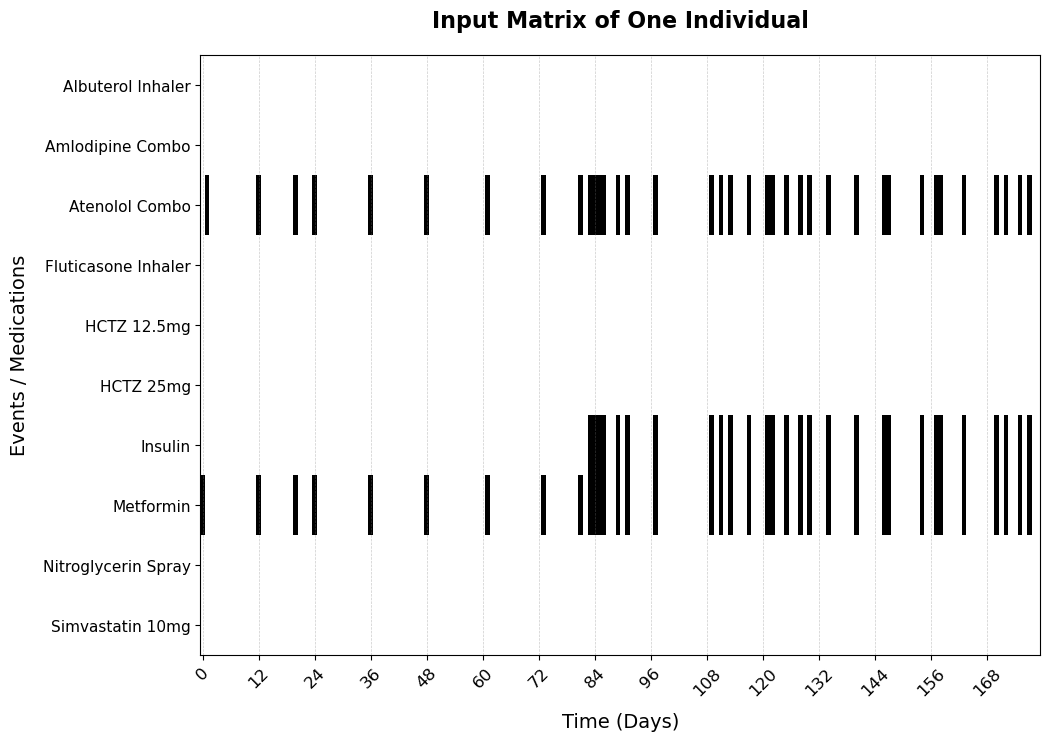

In [12]:
patient_index = int(patients_complets[0])
print(f"Patient used for visualization : {patient_index}")
plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded, time_unit='Days')

The matrix for Patient No. 21 clearly illustrates the multidimensional nature of the data: multiple treatments can be active simultaneously at any given time. Here, for example, we see that in Day 84, the patient is receiving Atenolol Combo, Insulin and Metformin at the same time.

## 4. Exploring SWoTTeD Hyperparameters

The values of $\alpha$ and $\gamma$ are calculated from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ using `compute_normalized_reg_terms`. Before running the simulations, we display the corresponding actual values to ensure they are within a reasonable order of magnitude.

Rather than exploring a fixed grid of combinations $(R, \omega, \tilde{\alpha}, \tilde{\gamma})$, we use the `optuna` library, which implements **Bayesian hyperparameter optimization**. Instead of blindly testing all combinations, the algorithm gradually learns which hyperparameters are promising. We use a **multi-objective approach** to find the optimal trade-offs (the Pareto front) between reconstruction accuracy, phenotype diversity, and active phenotype balance.

We jointly optimize $R \in \{3, 4, 5, 6, 7\}$, $\omega \in [7, 30]$, $\tilde{\alpha}$, and $\tilde{\gamma}$ within a budget of 50 trials. The optimization algorithm independently maximizes three criteria:

$$\text{Objectives} = (\text{FIT}_X, \text{div}(\mathcal{P}), \text{bal}(\mathcal{P}))$$

where $\text{div}(\mathcal{P})$ is the average cosine diversity, and $\text{bal}(\mathcal{P})$ is a balance term that we want to maximize:

$$\text{bal}(\mathcal{P}) = \frac{\displaystyle\frac{1}{R}\sum_{r=1}^{R} \|\tilde{p}_r\|_1}{\displaystyle\max_r \|\tilde{p}_r\|_1}$$

ou à tester 

$$\text{bal}(\mathcal{P}) = \frac{\displaystyle\min_r \|\tilde{p}_r\|_1}{\displaystyle\max_r \|\tilde{p}_r\|_1}$$

By optimizing these three metrics simultaneously, the algorithm prevents high diversity or balance from masking a poor reconstruction, and instead identifies the most robust compromises for the trajectory clustering.

The best model state is saved for each run via the checkpoint mechanism, and all results are aggregated into a DataFrame. To facilitate comparison, the trials are sorted primarily by descending $\text{FIT}_X$, followed by diversity and balance.

In [13]:
K = tca.analyzer.K
T = tca.analyzer.T
N = tca.analyzer.N

for R in [3, 5, 7]:
    for omega in [7, 14, 30]:
        facteur_alpha = (K * T) / (R * omega)
        facteur_gamma = N / R
        print(f"R={R}, ω={omega} → facteur_α={facteur_alpha:.0f}, facteur_γ={facteur_gamma:.2f}")

R=3, ω=7 → facteur_α=7723, facteur_γ=3.33
R=3, ω=14 → facteur_α=3861, facteur_γ=3.33
R=3, ω=30 → facteur_α=1802, facteur_γ=3.33
R=5, ω=7 → facteur_α=4634, facteur_γ=2.00
R=5, ω=14 → facteur_α=2317, facteur_γ=2.00
R=5, ω=30 → facteur_α=1081, facteur_γ=2.00
R=7, ω=7 → facteur_α=3310, facteur_γ=1.43
R=7, ω=14 → facteur_α=1655, facteur_γ=1.43
R=7, ω=30 → facteur_α=772, facteur_γ=1.43


In [14]:
for R in [3, 5, 7]:
    for omega in [7, 14, 30]:
        for alpha_rel, gamma_rel in [(1e-5, 0.1), (1e-4, 0.5), (2e-4, 2.0)]:
            a, g = compute_normalized_reg_terms(K, T, N, R=R, omega=omega,
                                                alpha_rel=alpha_rel, gamma_rel=gamma_rel)
            print(f"R={R}, ω={omega}, α_rel={alpha_rel} → α={a:.4f}, γ={g:.4f}")

R=3, ω=7, α_rel=1e-05 → α=0.0772, γ=0.3333
R=3, ω=7, α_rel=0.0001 → α=0.7723, γ=1.6667
R=3, ω=7, α_rel=0.0002 → α=1.5446, γ=6.6667
R=3, ω=14, α_rel=1e-05 → α=0.0386, γ=0.3333
R=3, ω=14, α_rel=0.0001 → α=0.3861, γ=1.6667
R=3, ω=14, α_rel=0.0002 → α=0.7723, γ=6.6667
R=3, ω=30, α_rel=1e-05 → α=0.0180, γ=0.3333
R=3, ω=30, α_rel=0.0001 → α=0.1802, γ=1.6667
R=3, ω=30, α_rel=0.0002 → α=0.3604, γ=6.6667
R=5, ω=7, α_rel=1e-05 → α=0.0463, γ=0.2000
R=5, ω=7, α_rel=0.0001 → α=0.4634, γ=1.0000
R=5, ω=7, α_rel=0.0002 → α=0.9267, γ=4.0000
R=5, ω=14, α_rel=1e-05 → α=0.0232, γ=0.2000
R=5, ω=14, α_rel=0.0001 → α=0.2317, γ=1.0000
R=5, ω=14, α_rel=0.0002 → α=0.4634, γ=4.0000
R=5, ω=30, α_rel=1e-05 → α=0.0108, γ=0.2000
R=5, ω=30, α_rel=0.0001 → α=0.1081, γ=1.0000
R=5, ω=30, α_rel=0.0002 → α=0.2162, γ=4.0000
R=7, ω=7, α_rel=1e-05 → α=0.0331, γ=0.1429
R=7, ω=7, α_rel=0.0001 → α=0.3310, γ=0.7143
R=7, ω=7, α_rel=0.0002 → α=0.6620, γ=2.8571
R=7, ω=14, α_rel=1e-05 → α=0.0165, γ=0.1429
R=7, ω=14, α_rel=0.0001 → α

Les facteurs de normalisation étant très grands pour $\alpha$ (entre 772 et 7723 selon la configuration), la plage explorable pour $\tilde{\alpha}$ est restreinte à $[10^{-5}, 2 \times 10^{-4}]$, ce qui correspond à des valeurs réelles de $\alpha$ comprises entre 0.01 et 1.5. Pour $\gamma$, le facteur $N/R$ variant entre 1.43 et 3.33, la plage $\tilde{\gamma} \in [0.1, 2.0]$ donne des valeurs réelles de $\gamma$ comprises entre 0.1 et 6.67, suffisamment large pour couvrir des régularisation faibles à fortes.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    rank      = trial.suggest_int('rank', 2, 5)
    twl       = trial.suggest_int('twl', 2, 10)
    alpha_rel = trial.suggest_float('alpha_rel', 1e-5, 2e-4, log=True)
    gamma_rel = trial.suggest_float('gamma_rel', 0.1, 2.0, log=True)

    alpha, gamma = compute_normalized_reg_terms(
        K=K, T=T, N=N,
        R=rank, omega=twl,
        alpha_rel=alpha_rel,
        gamma_rel=gamma_rel,
    )

    result = run_swotted_trial(
        timed_event_structure,
        rank=rank, time_window_length=twl,
        reg_ns=gamma, reg_s=alpha,
        lr=1e-2, n_epochs=500,
        early_stopping=True,
        fit_metric_every_n_epochs=10,
        early_stopping_patience=10,
    )

    result['alpha_rel'] = alpha_rel
    result['gamma_rel'] = gamma_rel
    result['alpha']     = alpha
    result['gamma']     = gamma

    trial.set_user_attr('result', result)

    fit_metric = result['best_fit_metric']
    # In case of failure, return penalizing values for the 3 objectives
    if fit_metric is None:
        return -999.0, 0.0, 0.0

    try:
        Ph_tensor = result['tca_trial'].analyzer.model.Ph.detach()
        div_cos, _ = phenotype_diversity(Ph_tensor)

        # Balance term: penalizes empty phenotypes without arbitrary threshold
        l1_norms = Ph_tensor.reshape(rank, -1).abs().sum(dim=1)
        balance  = (l1_norms.mean() / (l1_norms.max() + 1e-12)).item()
    except Exception:
        div_cos = 0.0
        balance = 0.0

    # Return the three metrics to maximize
    return fit_metric, div_cos, balance


study = optuna.create_study(directions=['maximize', 'maximize', 'maximize'])
study.optimize(objective, n_trials=10)


all_results = []
pareto_trial_numbers = [t.number for t in study.best_trials]

for t in study.trials:
    if 'result' not in t.user_attrs or t.values is None:
        continue
        
    row = t.user_attrs['result'].copy()
    
    # We extract the optimized values
    row['fit_metric'] = t.values[0]
    row['div_cos']    = t.values[1]
    row['balance']    = t.values[2]
    
    row['is_pareto']  = t.number in pareto_trial_numbers
    
    all_results.append(row)

# We sort by : fit_metric, diversity and balance
results_optuna_df = (pd.DataFrame(all_results)
                       .sort_values(by=['fit_metric', 'div_cos', 'balance'], ascending=[False, False, False])
                       .reset_index(drop=True))

display(results_optuna_df.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=3, reg_ns=4.208659843376013, reg_s=0.15064311081889384, learning_rate=0.01
Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 15241.966797 - train_loss_W: 29394.712891 - train_loss_total: 44636.679688 - duration: 2.60s - FIT metric: 0.0422 - ||P||_1: 97.1019 - S(X): 0.0595
    early stopping: Metric fit_metric initialized at 0.042.
    checkpoint: New best FIT metric = 0.0422 at epoch 1.
    lr_scheduler: learning rate = 1.00e-02
Epoch 2/500 : - train_loss_Ph: 12338.203125 - train_loss_W: 26059.875000 - train_loss_total: 38398.078125 - duration: 2.20s - ||P||_1: 64.5251 - S(X): 0.7818
    lr_scheduler: learning rate = 1.00e-02
Epoch 3/500 : - train_loss_Ph: 8749.923828 - train_loss_W: 22022.826172 - train_loss_total: 30772.750000 - duration: 2.15s - ||P||_1: 35.7139 - S(X): 0.5593
    lr_scheduler: learning rate = 1.00e-02
Epoch 4/500 : - train_loss_Ph: 4538.747559 - train_loss_W: 17431.103516 - train_loss_total: 21969.851074 - duration: 2.14s - ||P||_1: 13.4307 - S(X): 2.1784
    lr_scheduler: learning rate = 1.00e-02
Epoch 5/500 : - train_loss_Ph: 1345.293335 - train_loss_W: 1

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,final_p_l1_norm,final_non_succession,elapsed_s,alpha_rel,gamma_rel,alpha,gamma,fit_metric,div_cos,balance,is_pareto
0,3,3,0.564031,0.540404,0.01,210,0.614937,110,0.609340,11.094227,153.734985,8550.06,0.000030,0.169209,0.540404,0.564031,0.614937,0.996964,0.458601,True
1,5,7,0.215733,0.089922,0.01,210,0.608961,110,0.610125,10.606421,429.116608,8949.56,0.000019,0.107866,0.089922,0.215733,0.608961,1.000000,0.286592,True
2,5,6,0.515994,0.442712,0.01,200,0.577962,100,0.578596,8.761127,333.733948,8451.25,0.000082,0.257997,0.442712,0.515994,0.577962,0.985709,0.313772,False
3,5,4,0.898313,0.437762,0.01,200,0.562888,100,0.563477,10.757839,149.858536,8405.82,0.000054,0.449157,0.437762,0.898313,0.562888,0.614389,0.299482,False
4,4,3,4.208660,0.150643,0.01,250,0.538901,150,0.549793,10.873528,11.835556,9947.74,0.000011,1.683464,0.150643,4.208660,0.538901,0.826974,0.413477,False
5,4,8,0.858517,0.272514,0.01,200,0.478500,100,0.480302,11.059541,184.603683,8493.66,0.000054,0.343407,0.272514,0.858517,0.478500,0.915756,0.457626,False
6,5,6,0.873206,0.321281,0.01,200,0.460260,100,0.464841,11.087716,155.157166,8531.50,0.000059,0.436603,0.321281,0.873206,0.460260,0.604952,0.431881,False
7,3,9,4.958882,0.318929,0.01,210,0.421646,110,0.429356,11.634324,26.726536,8868.12,0.000053,1.487665,0.318929,4.958882,0.421646,0.334619,0.741230,True
8,4,8,0.287024,0.244069,0.01,210,0.396072,110,0.400438,4.875278,566.803467,8901.74,0.000048,0.114810,0.244069,0.287024,0.396072,0.590361,0.279772,False
9,2,7,0.509697,0.123635,0.01,210,0.352542,110,0.351903,6.151484,153.101379,8521.14,0.000011,0.101939,0.123635,0.509697,0.352542,1.000000,0.500000,True


=== Meilleure configuration ===
rank      : 3
twl       : 3
alpha_rel : 3.00e-05
gamma_rel : 1.69e-01
alpha     : 5.40e-01
gamma     : 5.64e-01
FIT_X     : 0.6149
div_cos  : 0.9970


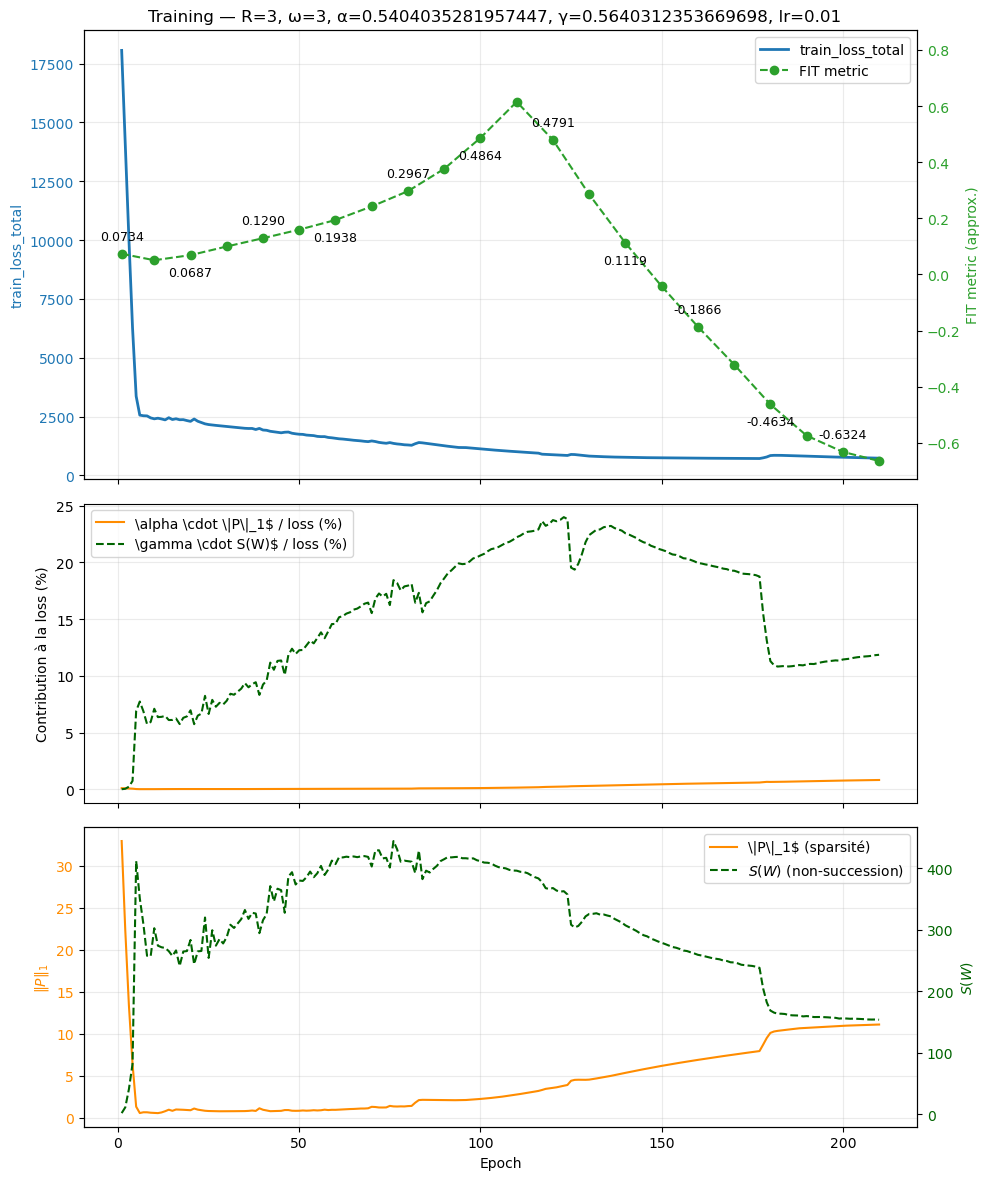

Decomposed into 901 pathways with rank 3 and time window length 3
Success rate for the entire dataset: 0.6092


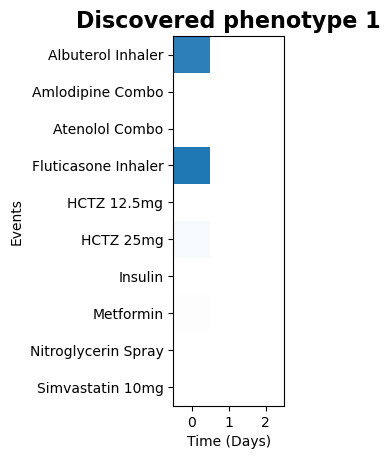

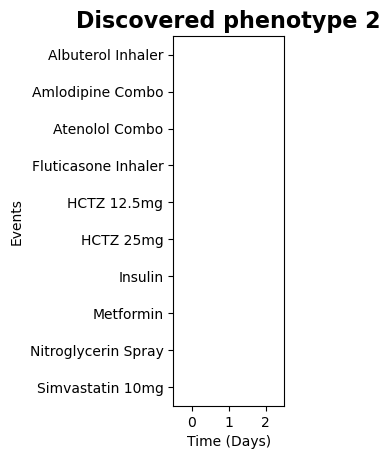

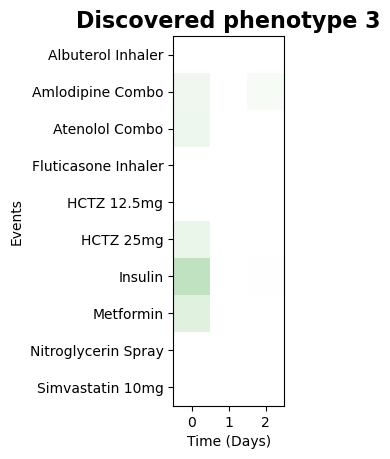

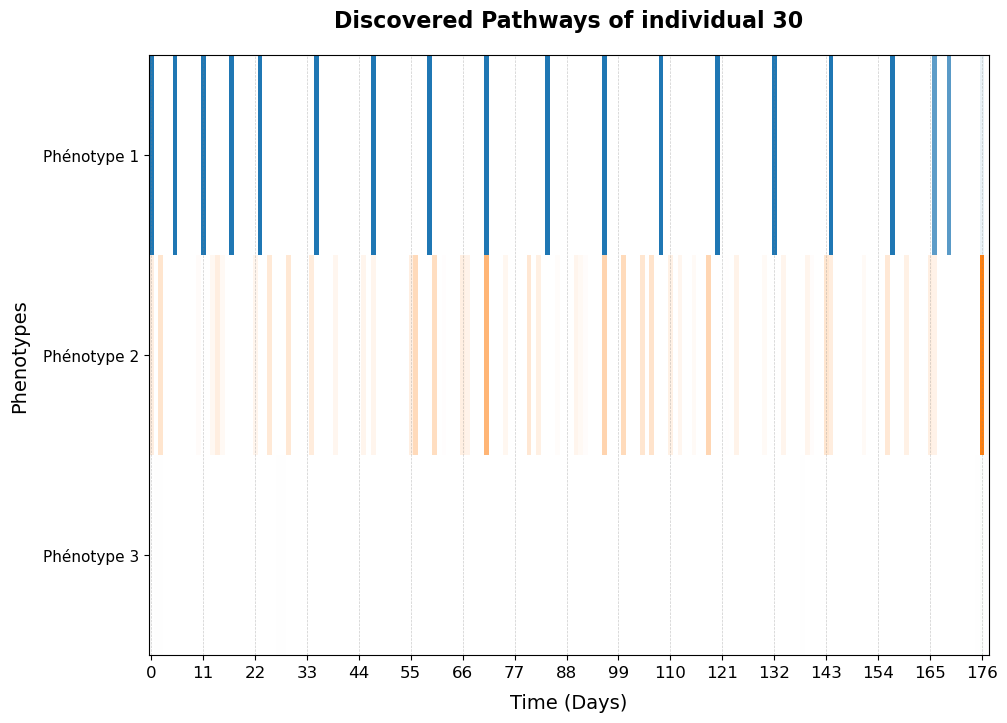

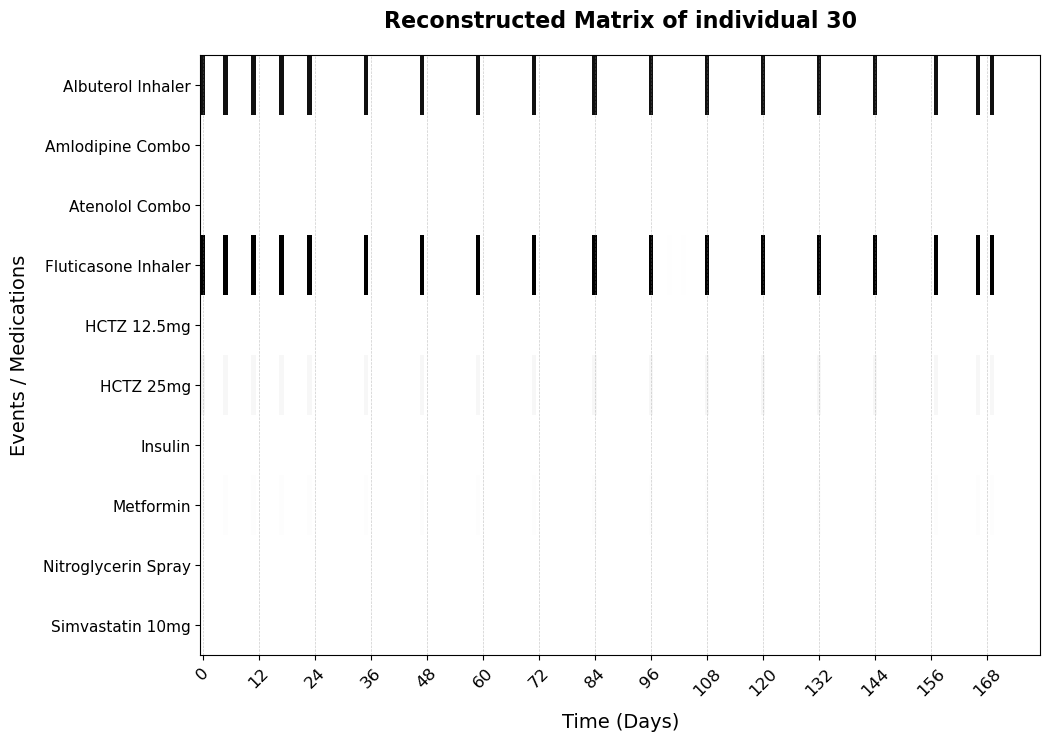

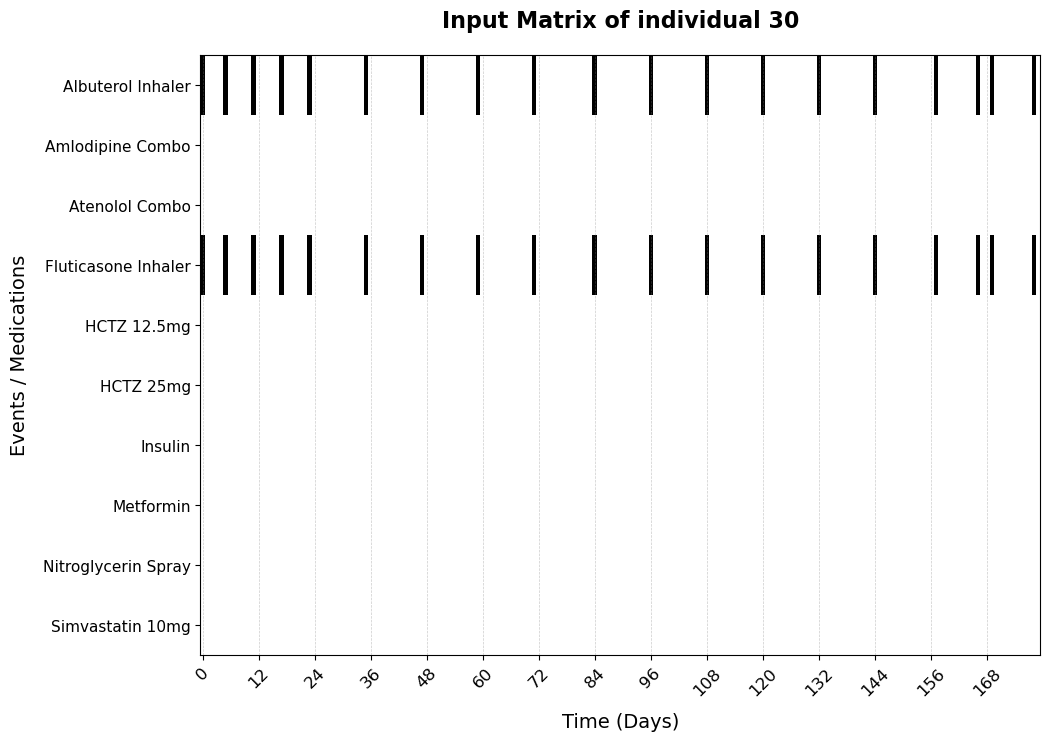

In [20]:
best = results_optuna_df.iloc[0]

print("=== Meilleure configuration ===")
print(f"rank      : {best['rank']}")
print(f"twl       : {best['time_window_length']}")
print(f"alpha_rel : {best['alpha_rel']:.2e}")
print(f"gamma_rel : {best['gamma_rel']:.2e}")
print(f"alpha     : {best['alpha']:.2e}")
print(f"gamma     : {best['gamma']:.2e}")
print(f"FIT_X     : {best['best_fit_metric']:.4f}")
print(f"div_cos  : {best['div_cos']:.4f}")

plot_training_history(best)

best['tca_trial'].analyzer.get_decomposition_results(
    labels=name_events, id=30, time_unit="Days"
)

## 5. Clustering Based on Phenotype Intensities

The ultimate goal of the SWoTTeD decomposition is to group patients into clinically interpretable clusters. Once the phenotypes have been learned, each patient $k$ is summarized by an intensity vector of size $R$, obtained by summing the activations of their matrix $W^{(k)}$ over the entire follow-up period and then normalizing the result. Clustering is applied to this compact representation.

In [17]:
from sklearn.preprocessing import MinMaxScaler

best_tca = best['tca_trial']

ph_intensity = best_tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler(feature_range=(0, 1)))
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (901, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.794914,0.391302,0.000401,1
1,0.847584,0.593717,0.000466,2
2,0.000614,0.482050,0.291269,3
3,0.806887,0.539850,0.000663,4
4,0.001222,0.492630,0.226974,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


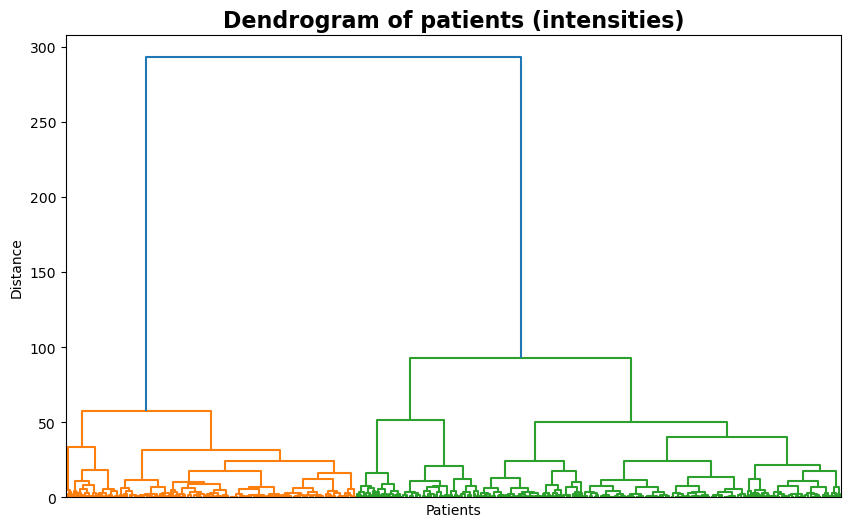

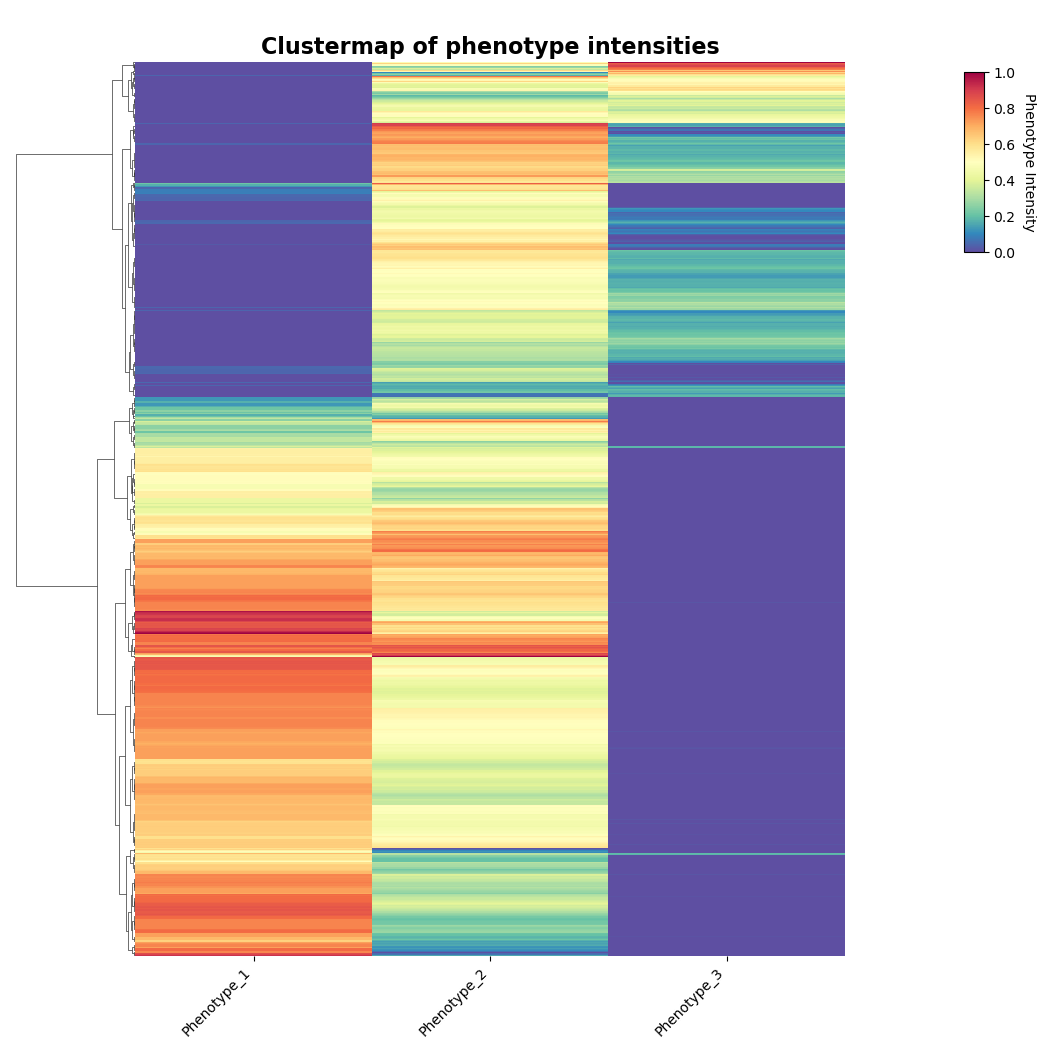

In [21]:
distance_matrix = best_tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = best_tca.hierarchical_clustering(distance_matrix)

best_tca.plot_dendrogram(linkage_matrix, title='Dendrogram of patients (intensities)')
best_tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap of phenotype intensities')

Effectifs par cluster:
1    338
2    143
3    420
Name: count, dtype: int64


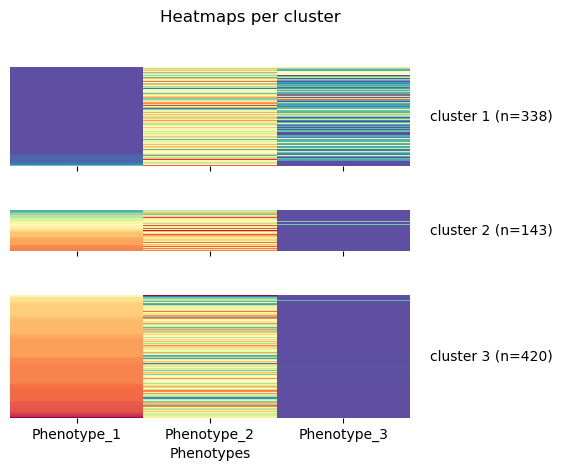

In [25]:
clusters = best_tca.assign_clusters(linkage_matrix, num_clusters=3)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

best_tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps per cluster')